In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
df.fillna("", inplace=True)

df['text'] = df['title'] + " " + df['description'] + " " + df['requirements']

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),   # capture phrases like "no experience"
    stop_words='english'
)

X = vectorizer.fit_transform(df['text'])
y = df['fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9656040268456376
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3395
           1       1.00      0.32      0.49       181

    accuracy                           0.97      3576
   macro avg       0.98      0.66      0.73      3576
weighted avg       0.97      0.97      0.96      3576



In [ ]:
def predict_job(text):
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)
    return "Fake Job" if prediction[0] == 1 else "Real Job"

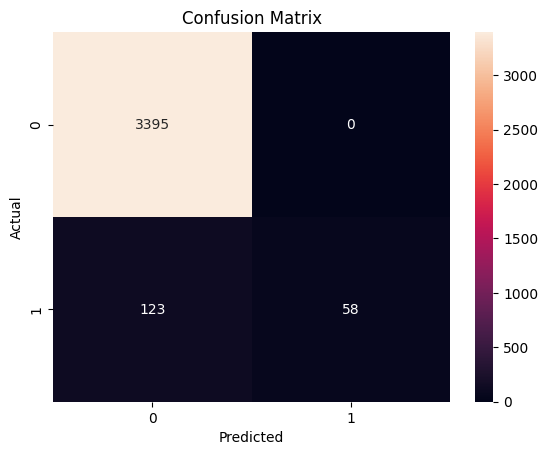

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3395
           1       1.00      0.32      0.49       181

    accuracy                           0.97      3576
   macro avg       0.98      0.66      0.73      3576
weighted avg       0.97      0.97      0.96      3576



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

In [ ]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_fake = sorted(zip(coefficients, feature_names), reverse=True)[:15]

print("Top words indicating FAKE job:")
for coef, word in top_fake:
    print(word)

Top words indicating FAKE job:
entry
money
engineering
from
gas
clerk
administrative
link
earn
clerical
subsea
oil
assistant
offshore
aker


              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.57      0.82      0.67       173

    accuracy                           0.96      3576
   macro avg       0.78      0.89      0.83      3576
weighted avg       0.97      0.96      0.96      3576



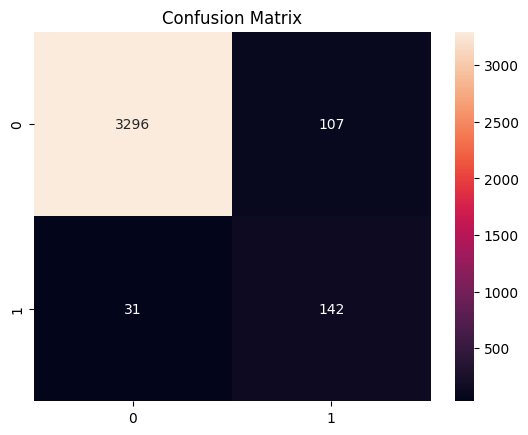

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Report:")
print(classification_report(y_test, nb_pred))

Naive Bayes Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      3403
           1       0.61      0.29      0.39       173

    accuracy                           0.96      3576
   macro avg       0.79      0.64      0.68      3576
weighted avg       0.95      0.96      0.95      3576



In [ ]:
def predict_job(text):
    vector = vectorizer.transform([text])
    prob = model.predict_proba(vector)[0][1]

    risk_score = prob * 100

    if prob > 0.7:
        level = "High Risk"
    elif prob > 0.4:
        level = "Medium Risk"
    else:
        level = "Low Risk"

    return f"Risk Score: {risk_score:.2f}% | {level}"

In [ ]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_fake_words = sorted(
    zip(coefficients, feature_names),
    reverse=True
)[:15]

print("Top Fake Indicators:")
for coef, word in top_fake_words:
    print(word)

Top Fake Indicators:
link
data entry
money
work home
engineering
clerk
high school
optical
assistant
offshore
center
hospital
gas
weather
earn


In [ ]:
fake_job = """
Urgent hiring!
no experience
no salary
pay 70"""

print(predict_job(fake_job))

Risk Score: 59.01% | Medium Risk
